In [1]:
# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

print("✅ TensorFlow Version:", tf.__version__)
print("✅ GPU Available:", tf.config.list_physical_devices('GPU'))

✅ TensorFlow Version: 2.19.0
✅ GPU Available: []


In [2]:
# Load Fashion-MNIST directly from Keras
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("✅ Dataset Loaded!")
print(f"   Training images   : {X_train.shape}")
print(f"   Training labels   : {y_train.shape}")
print(f"   Testing images    : {X_test.shape}")
print(f"   Testing labels    : {y_test.shape}")
print(f"   Pixel value range : {X_train.min()} to {X_train.max()}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Dataset Loaded!
   Training images   : (60000, 28, 28)
   Training labels   : (60000,)
   Testing images    : (10000, 28, 28)
   Testing labels    : (10000,)
   Pixel value range : 0 to 255


In [3]:
# Define all 10 clothing categories
class_names = [
    'T-shirt',   # 0
    'Trouser',   # 1
    'Pullover',  # 2
    'Dress',     # 3
    'Coat',      # 4
    'Sandal',    # 5
    'Shirt',     # 6
    'Sneaker',   # 7
    'Bag',       # 8
    'Ankle Boot' # 9
]

print("✅ 10 Classes:")
for i, name in enumerate(class_names):
    print(f"   {i} → {name}")

✅ 10 Classes:
   0 → T-shirt
   1 → Trouser
   2 → Pullover
   3 → Dress
   4 → Coat
   5 → Sandal
   6 → Shirt
   7 → Sneaker
   8 → Bag
   9 → Ankle Boot


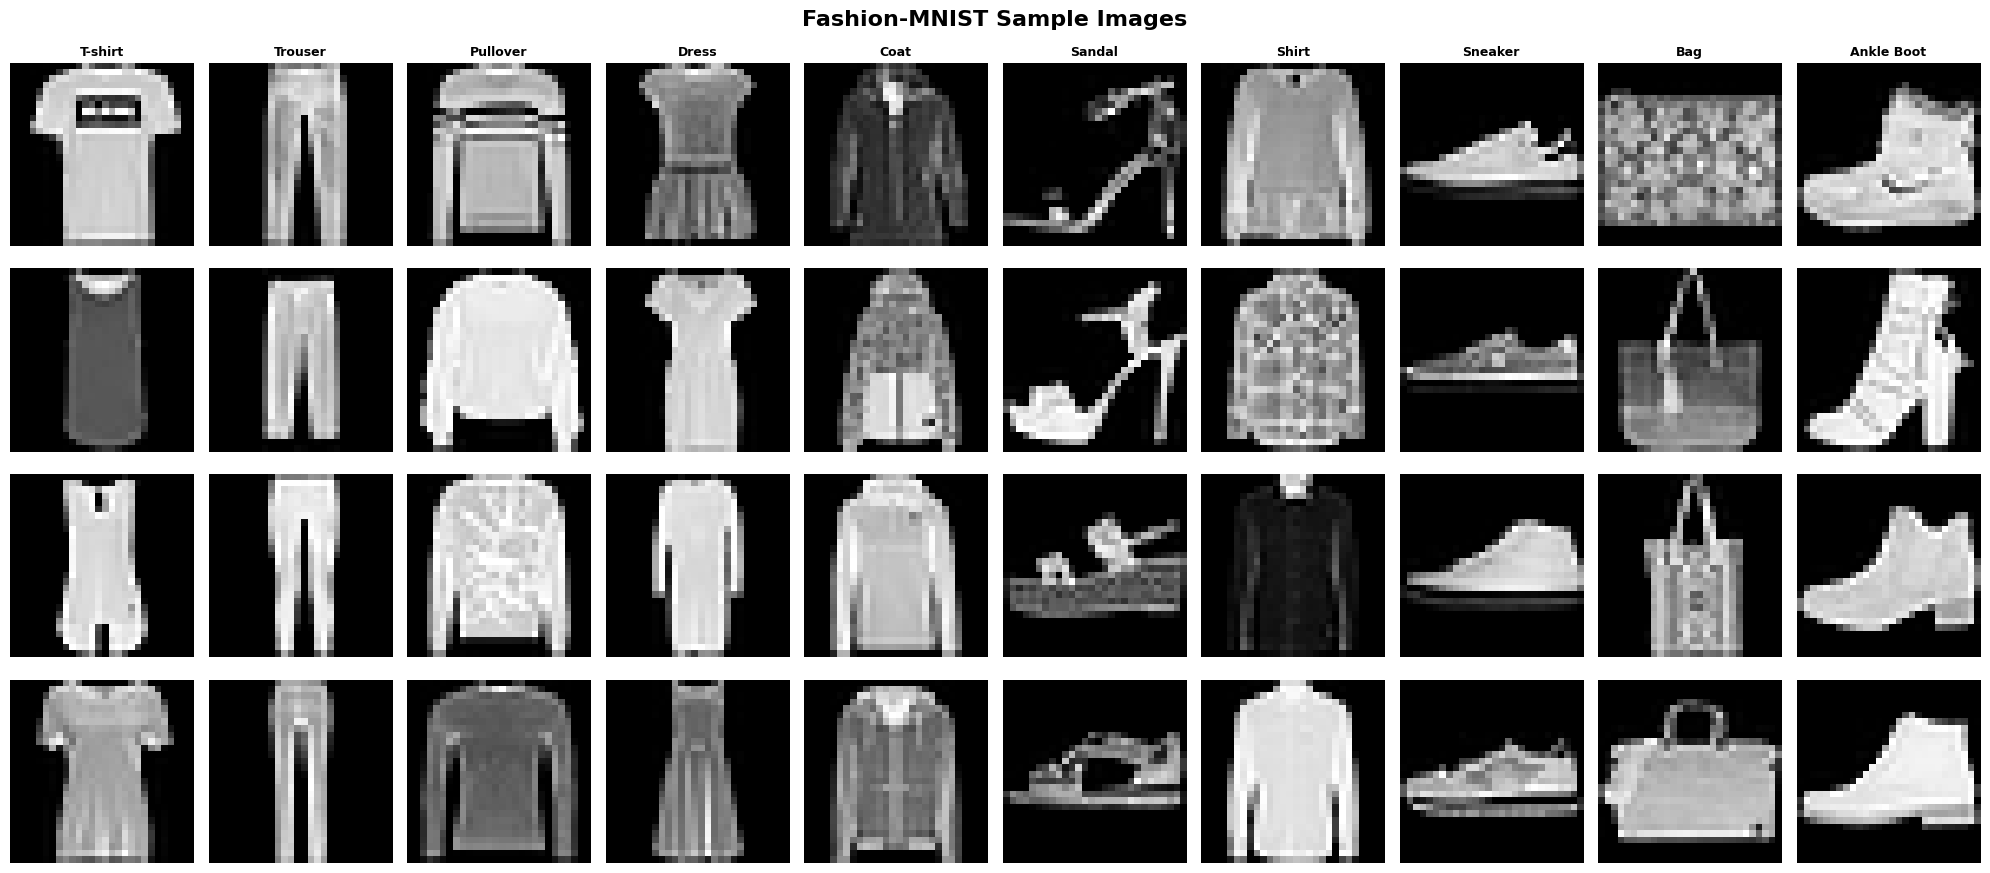

✅ Sample images displayed!


In [4]:
# Show sample images from dataset
fig, axes = plt.subplots(4, 10, figsize=(20, 9))
fig.suptitle('Fashion-MNIST Sample Images',
             fontsize=16, fontweight='bold')

for i in range(10):
    # find 4 examples of each class
    indices = np.where(y_train == i)[0][:4]
    for j, idx in enumerate(indices):
        axes[j][i].imshow(X_train[idx], cmap='gray')
        axes[j][i].axis('off')
        if j == 0:
            axes[j][i].set_title(class_names[i],
                                  fontsize=9,
                                  fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Sample images displayed!")

In [5]:
# Step 1: Reshape — add channel dimension
# CNN needs (height, width, channels)
# Grayscale = 1 channel (RGB = 3 channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# Step 2: Normalize pixel values 0-255 → 0-1
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Step 3: One-hot encode labels
# 7 → [0,0,0,0,0,0,0,1,0,0]
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

print("✅ Preprocessing Complete!")
print(f"   X_train shape : {X_train.shape}")
print(f"   X_test shape  : {X_test.shape}")
print(f"   y_train shape : {y_train_cat.shape}")
print(f"\n   Example label encoding:")
print(f"   Original : {y_train[0]} ({class_names[y_train[0]]})")
print(f"   Encoded  : {y_train_cat[0]}")

✅ Preprocessing Complete!
   X_train shape : (60000, 28, 28, 1)
   X_test shape  : (10000, 28, 28, 1)
   y_train shape : (60000, 10)

   Example label encoding:
   Original : 9 (Ankle Boot)
   Encoded  : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [6]:
# All settings in one place
IMG_SHAPE  = (28, 28, 1)   # height, width, channels
NUM_CLASSES = 10            # 10 clothing types
BATCH_SIZE  = 32            # images per step
EPOCHS      = 20            # training rounds

print("✅ Configuration:")
print(f"   Image Shape  : {IMG_SHAPE}")
print(f"   Classes      : {NUM_CLASSES}")
print(f"   Batch Size   : {BATCH_SIZE}")
print(f"   Epochs       : {EPOCHS}")
print(f"   Steps/Epoch  : {60000 // BATCH_SIZE}")

✅ Configuration:
   Image Shape  : (28, 28, 1)
   Classes      : 10
   Batch Size   : 32
   Epochs       : 20
   Steps/Epoch  : 1875


In [7]:
# MODEL 1: Baseline CNN
# Simple architecture — Conv → Pool → Flatten → Dense
def build_baseline_cnn():
    model = models.Sequential([

        # Convolution Block
        layers.Conv2D(32, (3,3),
                      activation='relu',
                      input_shape=IMG_SHAPE),
        # 32 filters, 3×3 kernel
        # detects basic edges and shapes
        # 28×28 → 26×26

        layers.MaxPooling2D(2, 2),
        # shrinks 26×26 → 13×13

        # Classifier
        layers.Flatten(),
        # 13×13×32 = 5408 → 1D vector

        layers.Dense(128, activation='relu'),
        # learns feature combinations

        layers.Dense(10, activation='softmax')
        # 10 outputs = 10 clothing classes
    ])
    return model

# Build and show
model1 = build_baseline_cnn()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# MODEL 2: CNN + Extra Convolution Layer
# More layers = learns more complex features
def build_extra_conv_cnn():
    model = models.Sequential([

        # Block 1 — detects basic features
        layers.Conv2D(32, (3,3),
                      activation='relu',
                      input_shape=IMG_SHAPE),
        # 28×28 → 26×26
        layers.MaxPooling2D(2, 2),
        # 26×26 → 13×13

        # Block 2 — detects complex features
        layers.Conv2D(64, (3,3),
                      activation='relu'),
        # 13×13 → 11×11
        # 64 filters now → more patterns detected
        layers.MaxPooling2D(2, 2),
        # 11×11 → 5×5

        # Classifier
        layers.Flatten(),
        # 5×5×64 = 1600 → 1D vector

        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model2 = build_extra_conv_cnn()
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# MODEL 3: CNN + Dropout
# Prevents overfitting by randomly
# turning off neurons during training
def build_dropout_cnn():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3),
                      activation='relu',
                      input_shape=IMG_SHAPE),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        # randomly turns off 25% neurons
        # forces model to learn robustly

        # Block 2
        layers.Conv2D(64, (3,3),
                      activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        # another 25% dropout

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        # 50% dropout in dense layer
        # strongest regularization here

        layers.Dense(10, activation='softmax')
    ])
    return model

model3 = build_dropout_cnn()
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# MODEL 4: CNN + Batch Normalization
# Normalizes layer outputs → faster stable training
def build_batchnorm_cnn():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3),
                      padding='same',
                      input_shape=IMG_SHAPE),
        layers.BatchNormalization(),
        # normalizes outputs before activation
        # keeps values in good range
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        # 28×28 → 14×14

        # Block 2
        layers.Conv2D(64, (3,3),
                      padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        # 14×14 → 7×7

        # Block 3
        layers.Conv2D(128, (3,3),
                      padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        # 7×7 → 3×3

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(10, activation='softmax')
    ])
    return model

model4 = build_batchnorm_cnn()
model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,330 (1.50 MB)

 Trainable params: 391,370 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
print("=" * 50)
print("🚀 Training Model 1: Baseline CNN")
print("=" * 50)

model1.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history1 = model1.fit(
    X_train, y_train_cat,
    batch_size      = BATCH_SIZE,
    epochs          = EPOCHS,
    validation_split= 0.2,
    # use 20% of training data for validation
    verbose         = 1
)

# Evaluate on test set
loss1, acc1 = model1.evaluate(
    X_test, y_test_cat, verbose=0)
print(f"\n✅ Baseline CNN Test Accuracy: {acc1*100:.2f}%")

🚀 Training Model 1: Baseline CNN
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.8476 - loss: 0.4318 - val_accuracy: 0.8884 - val_loss: 0.3183
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.8957 - loss: 0.2915 - val_accuracy: 0.9022 - val_loss: 0.2791
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.9111 - loss: 0.2424 - val_accuracy: 0.8907 - val_loss: 0.3037
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.9226 - loss: 0.2110 - val_accuracy: 0.9088 - val_loss: 0.2513
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.9346 - loss: 0.1827 - val_accuracy: 0.8989 - val_loss: 0.2875
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9410 - loss: 0.1582 - val_accuracy: 0.9144 - val_loss: 0.2447
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9505 - loss: 0.1353 - val_accuracy: 0.9168 - val_loss: 0.2442
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3

In [12]:
print("=" * 50)
print("🚀 Training Model 2: CNN + Extra Conv Layer")
print("=" * 50)

model2.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history2 = model2.fit(
    X_train, y_train_cat,
    batch_size       = BATCH_SIZE,
    epochs           = EPOCHS,
    validation_split = 0.2,
    verbose          = 1
)

loss2, acc2 = model2.evaluate(
    X_test, y_test_cat, verbose=0)
print(f"\n✅ Extra Conv Layer Accuracy: {acc2*100:.2f}%")

🚀 Training Model 2: CNN + Extra Conv Layer
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.8254 - loss: 0.4821 - val_accuracy: 0.8600 - val_loss: 0.3867
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.8842 - loss: 0.3156 - val_accuracy: 0.8868 - val_loss: 0.3095
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.9022 - loss: 0.2684 - val_accuracy: 0.8966 - val_loss: 0.2837
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - accuracy: 0.9132 - loss: 0.2349 - val_accuracy: 0.9052 - val_loss: 0.2566
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9225 - loss: 0.2080 - val_accuracy: 0.9080 - val_loss: 0.2570
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9314 - loss: 0.1840 - val_accuracy: 0.9111 - val_loss: 0.2546
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9398 - loss: 0.1627 - val_accuracy: 0.9129 - val_loss: 0.2445
Epoch 8/20
1500/1500 ━━━━━━━━━━━━

In [13]:
print("=" * 50)
print("🚀 Training Model 3: CNN + Dropout")
print("=" * 50)

model3.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history3 = model3.fit(
    X_train, y_train_cat,
    batch_size       = BATCH_SIZE,
    epochs           = EPOCHS,
    validation_split = 0.2,
    verbose          = 1
)

loss3, acc3 = model3.evaluate(
    X_test, y_test_cat, verbose=0)
print(f"\n✅ CNN + Dropout Accuracy: {acc3*100:.2f}%")

🚀 Training Model 3: CNN + Dropout
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7596 - loss: 0.6566 - val_accuracy: 0.8507 - val_loss: 0.4109
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.8330 - loss: 0.4626 - val_accuracy: 0.8706 - val_loss: 0.3606
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.8525 - loss: 0.4019 - val_accuracy: 0.8756 - val_loss: 0.3321
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.8648 - loss: 0.3731 - val_accuracy: 0.8884 - val_loss: 0.3064
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.8727 - loss: 0.3504 - val_accuracy: 0.8918 - val_loss: 0.2891
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.8768 - loss: 0.3370 - val_accuracy: 0.8928 - val_loss: 0.2888
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 86s 33ms/step - accuracy: 0.8795 - loss: 0.3232 - val_accuracy: 0.8962 - val_loss: 0.2765
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 

In [14]:
print("=" * 50)
print("🚀 Training Model 4: CNN + Batch Normalization")
print("=" * 50)

model4.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history4 = model4.fit(
    X_train, y_train_cat,
    batch_size       = BATCH_SIZE,
    epochs           = EPOCHS,
    validation_split = 0.2,
    verbose          = 1
)

loss4, acc4 = model4.evaluate(
    X_test, y_test_cat, verbose=0)
print(f"\n✅ Batch Normalization Accuracy: {acc4*100:.2f}%")

🚀 Training Model 4: CNN + Batch Normalization
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 118s 76ms/step - accuracy: 0.8626 - loss: 0.3850 - val_accuracy: 0.8648 - val_loss: 0.3949
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 114s 76ms/step - accuracy: 0.9012 - loss: 0.2742 - val_accuracy: 0.8538 - val_loss: 0.3784
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 113s 75ms/step - accuracy: 0.9159 - loss: 0.2337 - val_accuracy: 0.9064 - val_loss: 0.2725
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 137s 72ms/step - accuracy: 0.9255 - loss: 0.2073 - val_accuracy: 0.8854 - val_loss: 0.3352
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 109s 73ms/step - accuracy: 0.9336 - loss: 0.1841 - val_accuracy: 0.8995 - val_loss: 0.2732
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 142s 73ms/step - accuracy: 0.9405 - loss: 0.1638 - val_accuracy: 0.9114 - val_loss: 0.2500
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 114s 76ms/step - accuracy: 0.9481 - loss: 0.1411 - val_accuracy: 0.9160 - val_loss: 0.2558
Epoch 8/20
1500/1500 ━━

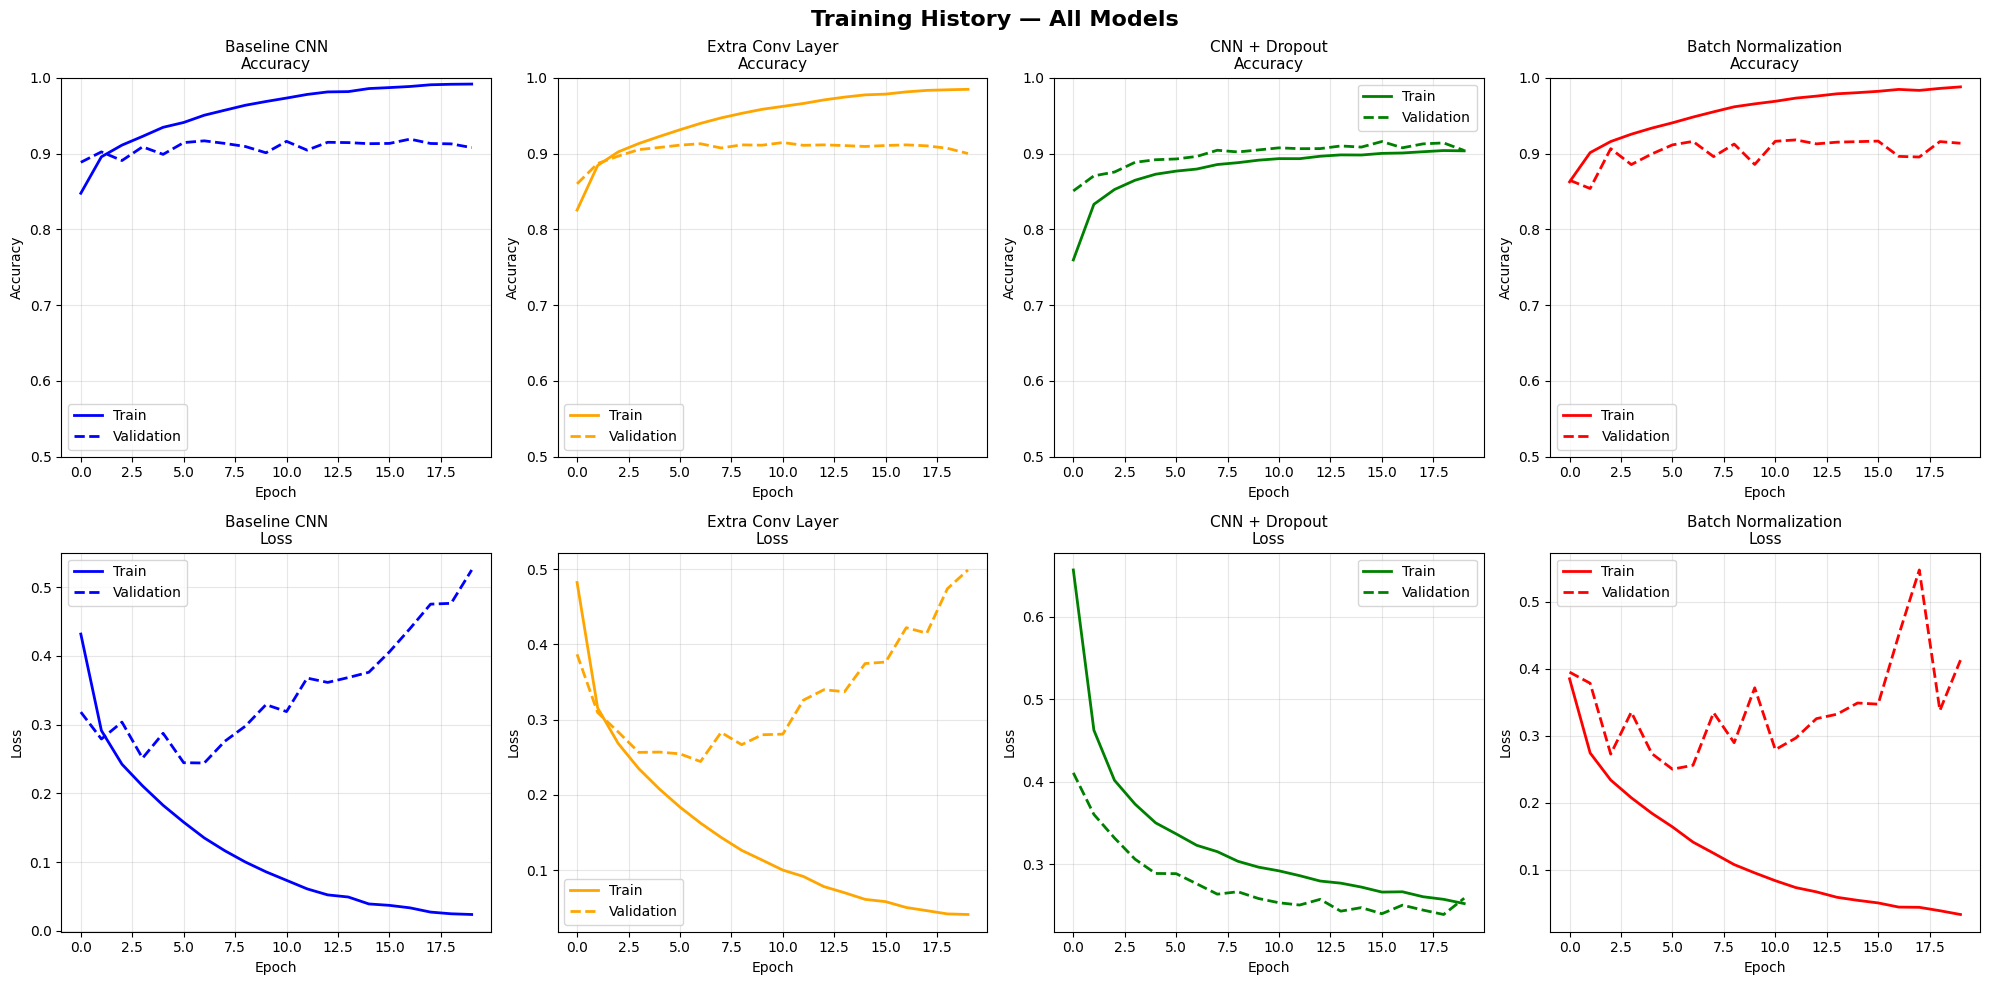

✅ Training curves saved!


In [15]:
# Plot all 4 models training history
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Training History — All Models',
             fontsize=16, fontweight='bold')

histories = [
    (history1, 'Baseline CNN',        'blue'),
    (history2, 'Extra Conv Layer',    'orange'),
    (history3, 'CNN + Dropout',       'green'),
    (history4, 'Batch Normalization', 'red')
]

for i, (hist, name, color) in enumerate(histories):

    # Accuracy plot (top row)
    axes[0][i].plot(
        hist.history['accuracy'],
        label='Train', color=color, linewidth=2)
    axes[0][i].plot(
        hist.history['val_accuracy'],
        label='Validation', color=color,
        linewidth=2, linestyle='--')
    axes[0][i].set_title(f'{name}\nAccuracy',
                          fontsize=11)
    axes[0][i].set_xlabel('Epoch')
    axes[0][i].set_ylabel('Accuracy')
    axes[0][i].legend()
    axes[0][i].set_ylim(0.5, 1.0)
    axes[0][i].grid(True, alpha=0.3)

    # Loss plot (bottom row)
    axes[1][i].plot(
        hist.history['loss'],
        label='Train', color=color, linewidth=2)
    axes[1][i].plot(
        hist.history['val_loss'],
        label='Validation', color=color,
        linewidth=2, linestyle='--')
    axes[1][i].set_title(f'{name}\nLoss',
                          fontsize=11)
    axes[1][i].set_xlabel('Epoch')
    axes[1][i].set_ylabel('Loss')
    axes[1][i].legend()
    axes[1][i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("✅ Training curves saved!")


Model                     Test Accuracy
Baseline CNN                   90.59%  
Extra Conv Layer               89.68%  
CNN + Dropout                  89.38%  
Batch Normalization            90.71%   ← 🏆 BEST

🏆 Best Model  : Batch Normalization
📈 Improvement : 1.33% over baseline


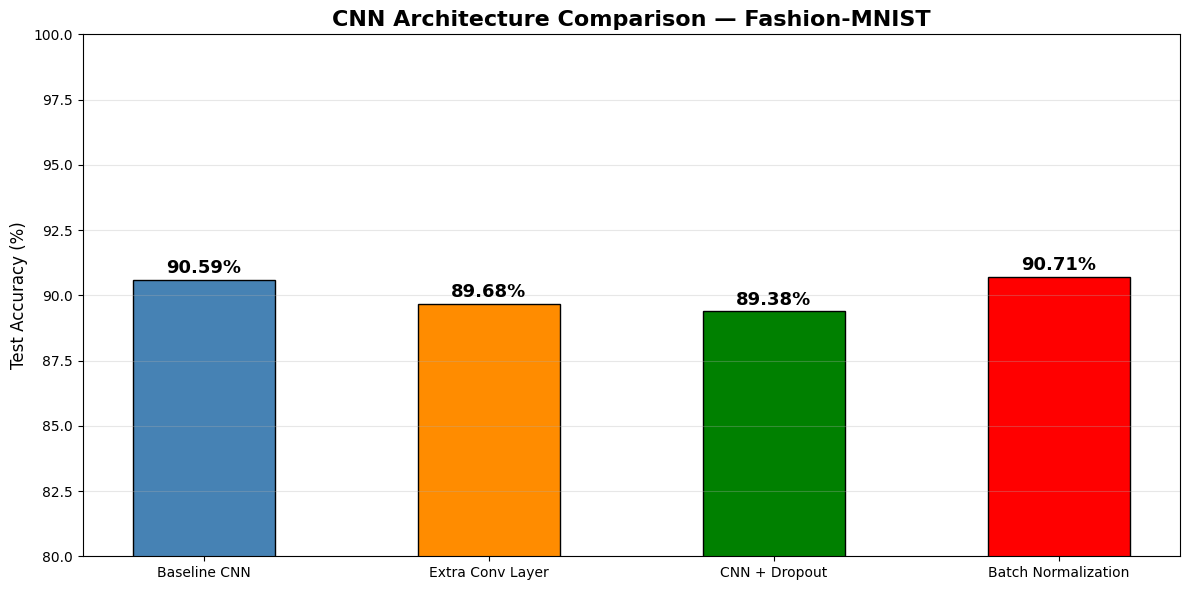

In [16]:
# Final results comparison
results = {
    'Baseline CNN':        round(acc1 * 100, 2),
    'Extra Conv Layer':    round(acc2 * 100, 2),
    'CNN + Dropout':       round(acc3 * 100, 2),
    'Batch Normalization': round(acc4 * 100, 2)
}

# Print comparison table
print("\n" + "="*50)
print(f"{'Model':<25} {'Test Accuracy':>12}")
print("="*50)
for name, acc in results.items():
    bar    = "█" * int(acc // 3)
    marker = " ← 🏆 BEST" if acc == max(results.values()) else ""
    print(f"{name:<25} {acc:>10}%  {marker}")
print("="*50)
print(f"\n🏆 Best Model  : "
      f"{max(results, key=results.get)}")
print(f"📈 Improvement : "
      f"{max(results.values()) - min(results.values()):.2f}%"
      f" over baseline")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['steelblue', 'darkorange', 'green', 'red']
bars   = ax.bar(results.keys(),
                results.values(),
                color=colors,
                width=0.5,
                edgecolor='black')

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val}%',
            ha='center', va='bottom',
            fontsize=13, fontweight='bold')

ax.set_title('CNN Architecture Comparison — Fashion-MNIST',
             fontsize=16, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_ylim(80, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

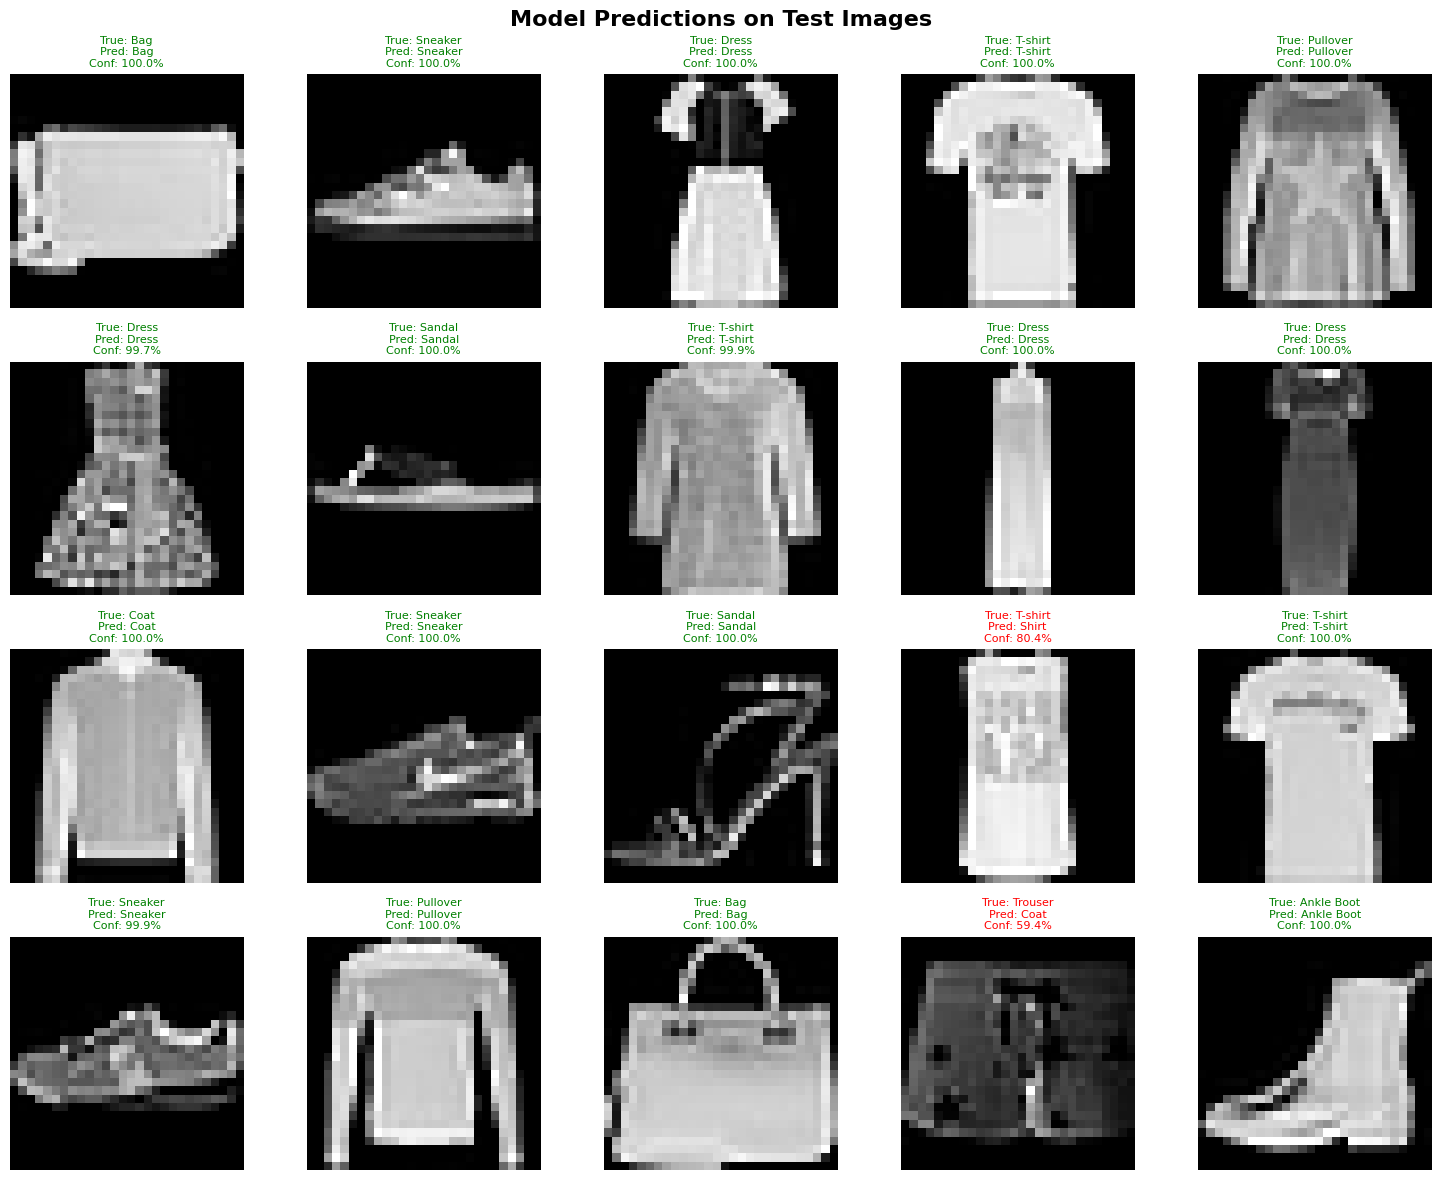

✅ Correct: 18/20 = 90%


In [17]:
# Test best model on real images
best_model = model4  # batch norm usually wins

# Get predictions
predictions = best_model.predict(X_test, verbose=0)

# Show 20 random predictions
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Model Predictions on Test Images',
             fontsize=16, fontweight='bold')

random_indices = np.random.choice(
    len(X_test), 20, replace=False)

for idx, ax in zip(random_indices, axes.flat):
    # Show image
    ax.imshow(X_test[idx].reshape(28, 28),
              cmap='gray')

    true_label = class_names[y_test[idx]]
    pred_label = class_names[np.argmax(
                             predictions[idx])]
    confidence = np.max(predictions[idx]) * 100

    # Green title = correct, Red = wrong
    color = 'green' if true_label == pred_label \
            else 'red'
    ax.set_title(
        f'True: {true_label}\n'
        f'Pred: {pred_label}\n'
        f'Conf: {confidence:.1f}%',
        fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()

# Count correct predictions
correct = sum(
    class_names[y_test[i]] ==
    class_names[np.argmax(predictions[i])]
    for i in random_indices
)
print(f"✅ Correct: {correct}/20 = {correct*5}%")